<table><tr><th><div style='padding:15px;color:#030aa7;font-size:240%;text-align:center;font-weight:bold;font-family:Georgia,serif'>Comparer et classer — Logs web</div></th></tr></table>
<table><tr><th><div style='padding:15px;color:#e50000;font-size:240%;text-align:center;font-style:italic;font-weight:bold;font-family:Georgia,serif'>Qui domine ou progresse ?</div></th></tr></table>

<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_1.png' width='1024'></div>
<div style='text-align:center'><img src='https://raw.githubusercontent.com/rbizoi/dockerBigDataBI/refs/heads/master/images/bi/famille_1_description.png' width='1024'></div>

<div style='padding:15px;color:#030aa7;font-family:Georgia,serif'>Atelier BI · Famille 01 · 6 graphiques × 3 bibliothèques</div>

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Introduction</div></b>

Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.

**Objectif :** construire les six représentations de cette famille sur les données réelles, comparer les encodages et interpréter leurs limites. Les trois variantes utilisent exactement la même table préparée. Les constructions composites Seaborn sont signalées : cette bibliothèque ne propose pas tous les types nativement.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Sommaire</div></b>

1. Barres horizontales ou colonnes
2. Barres groupées
3. Points alignés ou dot plot
4. Sucettes ou lollipop
5. Pentes ou slopegraph
6. Haltères ou dumbbell

Exécution : ouvrir le dossier extrait, sélectionner un noyau Python avec les dépendances de `requirements.txt`, puis **Redémarrer le noyau et tout exécuter**. Les résultats sont déjà enregistrés. Adapter `config_donnees.json` si les fichiers changent de place.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Import des bibliothèques</div></b>

In [1]:
NOM_PROJET = '01_web'
from pathlib import Path
import os, json, warnings
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Wedge
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde
import networkx as nx
import squarify

get_ipython().run_line_magic('matplotlib', 'inline')
SEED = 42
palette = ["#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
           "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#c071fe"]
sns.set_theme(style='darkgrid', palette=palette, context='notebook', font_scale=1.05)
plt.rcParams.update({'figure.figsize': (11, 5), 'figure.dpi': 110})
pio.templates['bi_modele'] = pio.templates['plotly_white']
pio.templates['bi_modele'].layout.colorway = palette
pio.templates.default = 'bi_modele'
pio.renderers.default = 'plotly_mimetype'
px.defaults.color_discrete_sequence = palette
EXPORTER = False  # True : PNG statiques et HTML interactifs dans repertoire.images.
repertoireImages = Path('repertoire.images') / NOM_PROJET

def sauvegarderImage(nom, fig=None):
    fig = fig if fig is not None else plt.gcf()
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.savefig(repertoireImages / (nom + '.png'), dpi=180, bbox_inches='tight')

def terminer(ax, titre, xlabel=None, ylabel=None):
    ax.set_title(titre, loc='left', fontweight='bold', pad=14)
    if xlabel is not None: ax.set_xlabel(xlabel)
    if ylabel is not None: ax.set_ylabel(ylabel)
    ax.figure.tight_layout()
    sauvegarderImage(ID_GRAPHIQUE + '_' + BIBLIOTHEQUE, ax.figure)
    plt.show()
    plt.close(ax.figure)

def montrer_plotly(fig, titre):
    fig.update_layout(title=titre, width=1000, height=520,
                      margin=dict(l=70, r=45, t=90, b=75),
                      font=dict(family='Arial', size=13))
    if EXPORTER:
        repertoireImages.mkdir(parents=True, exist_ok=True)
        fig.write_html(repertoireImages / (ID_GRAPHIQUE + '_plotly.html'), include_plotlyjs=True)
    fig.show()

def creer_axes(seaborn=False, **kwargs):
    # Matplotlib reste autonome ; Seaborn garde le style et la palette du modèle.
    plt.style.use('default')
    if seaborn: sns.set_theme(style='darkgrid', palette=palette, context='notebook')
    return plt.subplots(figsize=(11, 5), **kwargs)

print('Versions :', 'pandas', pd.__version__, 'seaborn', sns.__version__,
      'plotly', __import__('plotly').__version__, 'matplotlib', __import__('matplotlib').__version__)

Versions : pandas 2.3.3 seaborn 0.13.2 plotly 7.1.0 matplotlib 3.10.9


## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Outils du document</div></b>

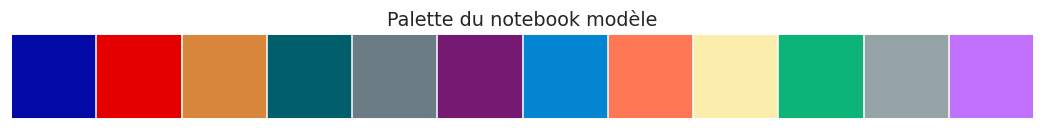

In [2]:
sns.palplot(sns.color_palette(palette))
plt.title('Palette du notebook modèle')
plt.show()
plt.close('all')

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Lecture des données</div></b>

<table><tr><th style="background:#053061;color:white">Colonne</th><th style="background:#053061;color:white">Description</th></tr><tr><td>datetime</td><td>Horodatage UTC</td></tr><tr><td>status / classe_http</td><td>Code HTTP et famille de code</td></tr><tr><td>bytes / taille_ko</td><td>Octets transférés et kilo-octets binaires (÷ 1024)</td></tr><tr><td>device_type / referer_type</td><td>Classe appareil et type de référent déjà présents dans le fichier</td></tr><tr><td>is_bot</td><td>Détection de robot fournie, non réestimée</td></tr><tr><td>geo_country_code / geo_latitude / geo_longitude</td><td>Géolocalisation fournie, indicative ; pas une position individuelle vérifiée</td></tr></table>

In [3]:
CHEMINS = {'meteo': '/opt/spark/data/meteo.gzip', 'web': '/opt/spark/data/Web.Server.Access10.gzip', 'ecommerce': '/opt/spark/notebooks/ecommerce'}
configuration = Path('config_donnees.json')
if configuration.exists():
    CHEMINS.update(json.loads(configuration.read_text(encoding='utf-8')))
for cle in CHEMINS:
    CHEMINS[cle] = os.environ.get('BI_' + cle.upper(), CHEMINS[cle])
assert Path(CHEMINS['web']).exists(), 'Vérifier config_donnees.json'

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Contrôle des données et préparation</div></b>

In [4]:
colonnes = ['datetime', 'method', 'status', 'bytes', 'device_type', 'referer_type',
            'is_bot', 'geo_country_code', 'geo_latitude', 'geo_longitude', 'url_parameter_count']
brut = pd.read_parquet(CHEMINS['web'], columns=colonnes)
donnees = brut.copy()
donnees['datetime'] = pd.to_datetime(donnees['datetime'], utc=True, errors='coerce')
valides = donnees['datetime'].notna() & donnees['status'].between(100, 599) & donnees['bytes'].ge(0)
print(f'Lignes source : {len(brut):,} ; hors critères techniques : {(~valides).sum():,}')
donnees = donnees.loc[valides].copy()
for col in ['method', 'device_type', 'referer_type', 'geo_country_code']:
    donnees[col] = donnees[col].fillna('Inconnu')
donnees['classe_http'] = (donnees['status'] // 100).astype(str) + 'xx'
donnees['erreur'] = donnees['status'].ge(400)
donnees['minute'] = donnees['datetime'].dt.floor('min')
donnees['taille_ko'] = donnees['bytes'] / 1024
print('Périmètre UTC :', donnees['datetime'].min(), '→', donnees['datetime'].max())
print('Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.')
assert len(donnees) > 0
display(donnees.describe(include='all').T)

Lignes source : 499,997 ; hors critères techniques : 0
Périmètre UTC : 2019-01-22 00:26:14+00:00 → 2019-01-22 07:36:14+00:00
Les requêtes ne sont pas des visiteurs ; les octets ne sont pas des temps de réponse.


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,499997,NaN,NaN,NaN,2019-01-22 05:36:38.271808768+00:00,2019-01-22 00:26:14+00:00,2019-01-22 04:49:36+00:00,2019-01-22 05:56:38+00:00,2019-01-22 06:49:12+00:00,2019-01-22 07:36:14+00:00,NaN
method,499997,5,GET,490457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,499997.0,<NA>,<NA>,<NA>,207.91811,200.0,200.0,200.0,200.0,504.0,34.678443
bytes,499997.0,<NA>,<NA>,<NA>,12771.083188,0.0,1955.0,3876.0,13126.0,1249490.0,26326.91015
device_type,499997,5,PC,321284,NaN,NaN,NaN,NaN,NaN,NaN,NaN
referer_type,499997,5,Internal,369107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_bot,499997,2,False,436678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_country_code,499997,76,IR,337870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
geo_latitude,496377.0,NaN,NaN,NaN,37.61343,-38.0365,35.698,35.698,37.751,66.0899,6.617004
geo_longitude,496377.0,NaN,NaN,NaN,21.131996,-123.1981,11.0783,51.4115,51.4115,174.7675,56.968638


# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Statistiques descriptives et analyse de données</div></b>

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>1 — Barres horizontales</div></b>

Comparer les volumes de requêtes par type d’appareil. Variables : appareil C + effectif Q ; zéro est l’origine des barres.

In [5]:
a = donnees.groupby('device_type').size().sort_values().rename('requetes').reset_index()
display(a)

,device_type,requetes
0,Other,3797
1,Tablet,18119
2,Bot,63319
3,Mobile,93478
4,PC,321284


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

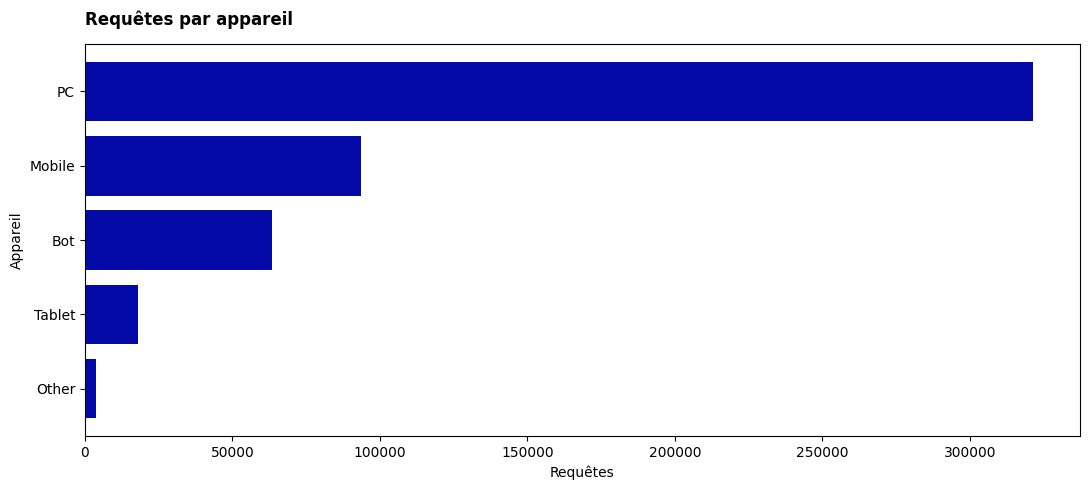

In [6]:
ID_GRAPHIQUE = '01_01'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig, ax = creer_axes()
ax.barh(a.device_type, a.requetes, color=palette[0])
terminer(ax, 'Requêtes par appareil', 'Requêtes', 'Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

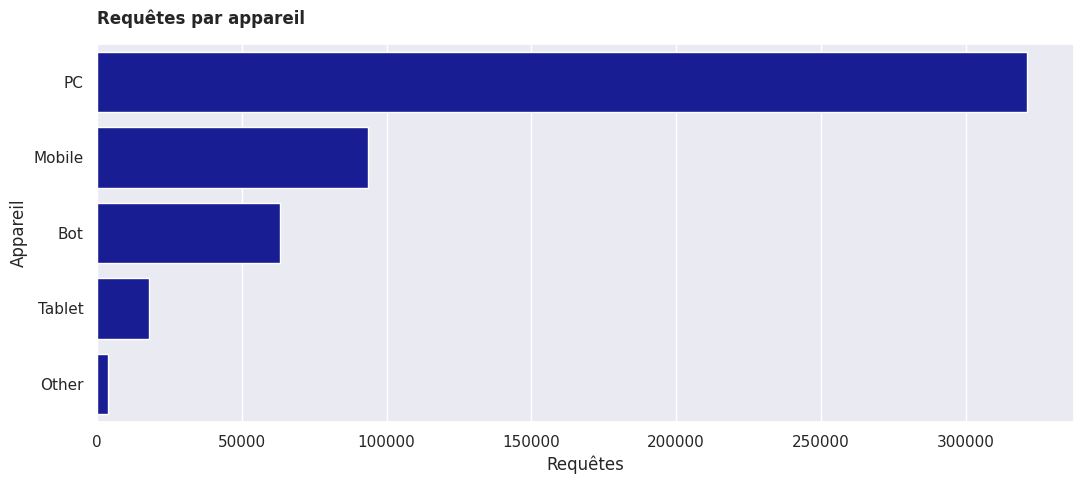

In [7]:
ID_GRAPHIQUE = '01_01'
BIBLIOTHEQUE = 'seaborn'
fig, ax = creer_axes(True)
sns.barplot(data=a, x='requetes', y='device_type', order=a.device_type, color=palette[0], errorbar=None, ax=ax)
ax.invert_yaxis()
terminer(ax, 'Requêtes par appareil', 'Requêtes', 'Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

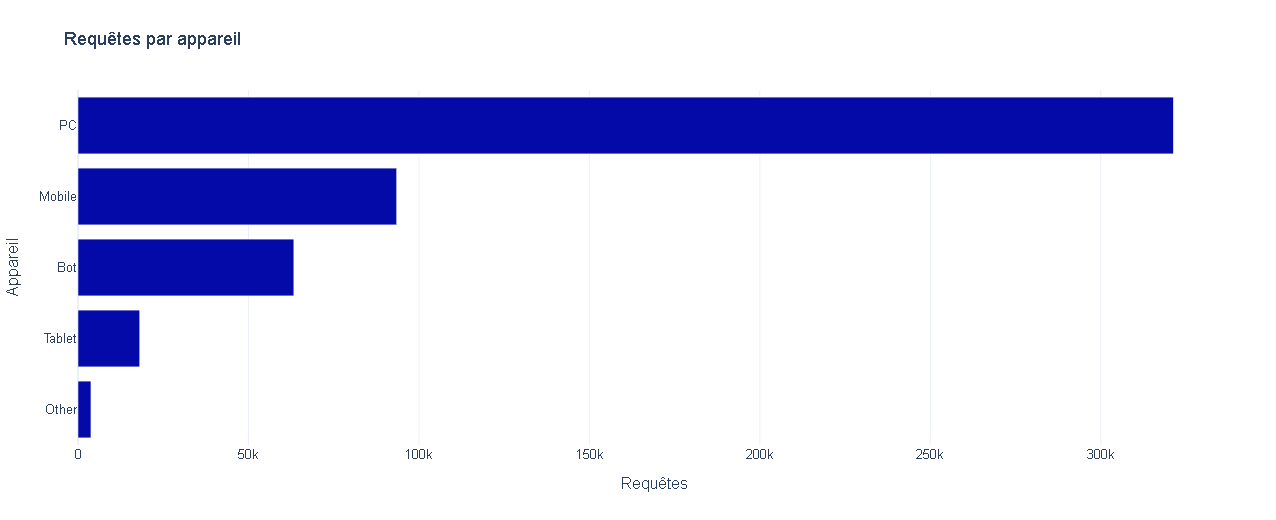

In [8]:
ID_GRAPHIQUE = '01_01'
BIBLIOTHEQUE = 'plotly'
fig = px.bar(a, x='requetes', y='device_type', orientation='h', labels={'requetes':'Requêtes','device_type':'Appareil'})
montrer_plotly(fig, 'Requêtes par appareil')

**À lire dans les trois variantes :** Comparer les volumes de requêtes par type d’appareil. Variables : appareil C + effectif Q ; zéro est l’origine des barres.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>2 — Barres groupées</div></b>

Comparer la composition HTTP des quatre appareils les plus fréquents. Variables : appareil C + classe HTTP C + effectif Q. Une échelle linéaire conserve les écarts réels.

In [9]:
top = donnees.device_type.value_counts().head(4).index
piv = pd.crosstab(donnees.device_type, donnees.classe_http).reindex(top, fill_value=0)
a = piv.rename_axis('appareil').reset_index().melt(id_vars='appareil', var_name='http', value_name='n')
display(piv)

classe_http,2xx,3xx,4xx,5xx
device_type,,,,
PC,312131,7284,1799,70
Mobile,88170,2134,3153,21
Bot,49254,12420,1637,8
Tablet,17641,174,301,3


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

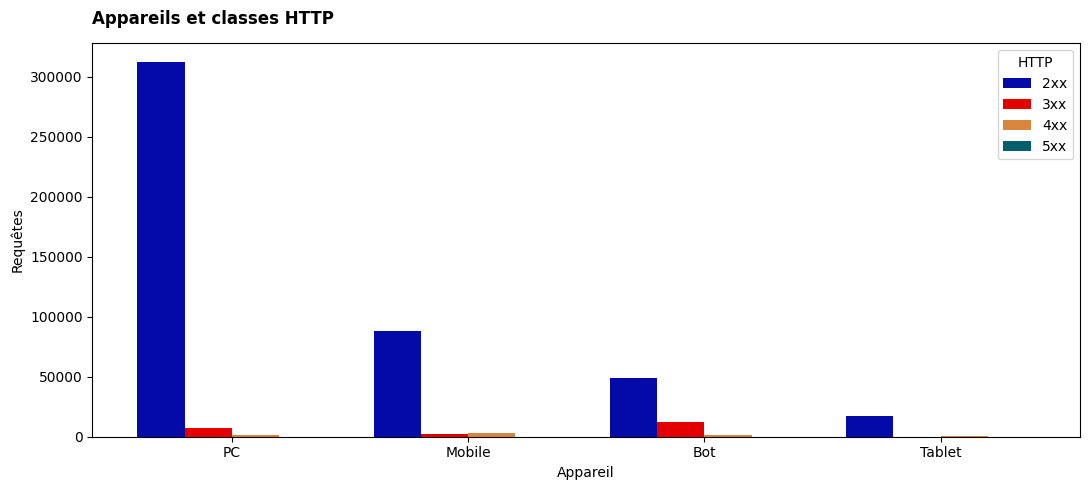

In [10]:
ID_GRAPHIQUE = '01_02'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig, ax = creer_axes()
x = np.arange(len(piv)); largeur = .8 / len(piv.columns)
for j, col in enumerate(piv): ax.bar(x + (j-(len(piv.columns)-1)/2)*largeur, piv[col], largeur, label=col, color=palette[j])
ax.set_xticks(x, piv.index); ax.legend(title='HTTP')
terminer(ax, 'Appareils et classes HTTP', 'Appareil', 'Requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

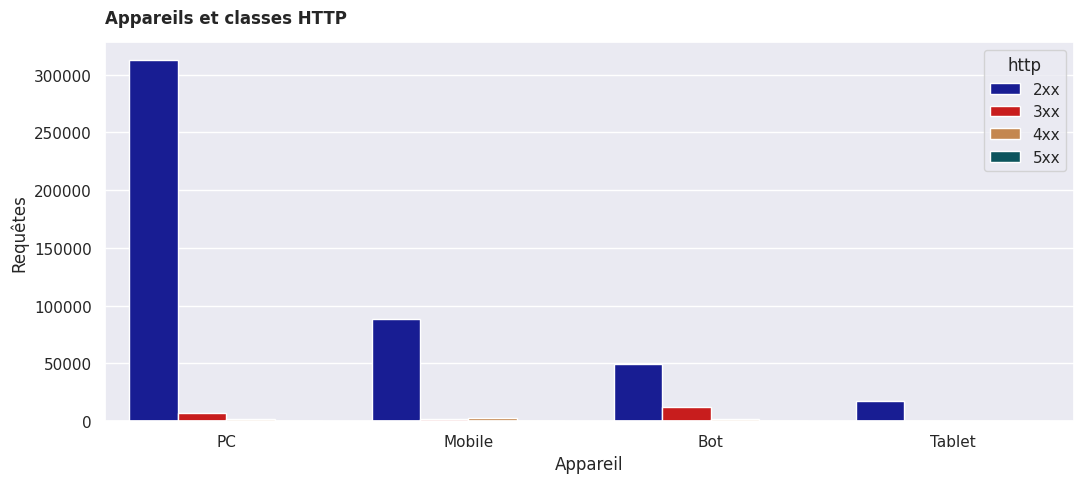

In [11]:
ID_GRAPHIQUE = '01_02'
BIBLIOTHEQUE = 'seaborn'
fig, ax = creer_axes(True)
sns.barplot(data=a, x='appareil', y='n', hue='http', errorbar=None, palette=palette[:len(piv.columns)], ax=ax)
terminer(ax, 'Appareils et classes HTTP', 'Appareil', 'Requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

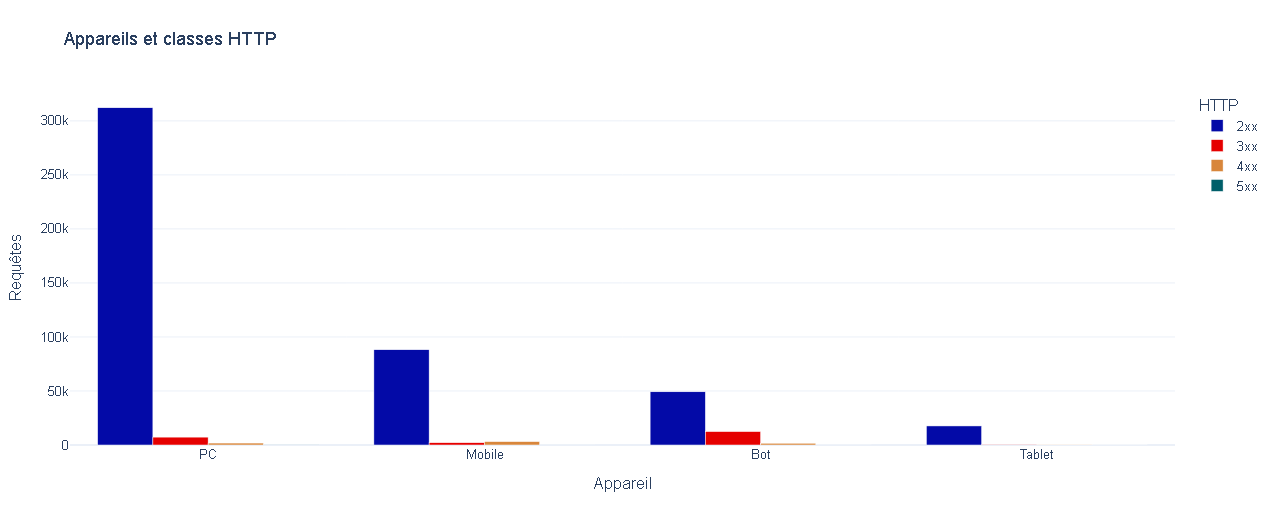

In [12]:
ID_GRAPHIQUE = '01_02'
BIBLIOTHEQUE = 'plotly'
fig = px.bar(a, x='appareil', y='n', color='http', barmode='group', labels={'n':'Requêtes','appareil':'Appareil','http':'HTTP'})
montrer_plotly(fig, 'Appareils et classes HTTP')

**À lire dans les trois variantes :** Comparer la composition HTTP des quatre appareils les plus fréquents. Variables : appareil C + classe HTTP C + effectif Q. Une échelle linéaire conserve les écarts réels.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>3 — Points alignés</div></b>

Comparer le taux HTTP 4xx/5xx par appareil. Variables : appareil C + taux Q ; les effectifs affichés permettent de juger les petits groupes.

In [13]:
a = donnees.groupby('device_type').agg(taux=('erreur','mean'), n=('status','size')).reset_index()
a['taux'] *= 100
a = a.sort_values('taux')
display(a)

,device_type,taux,n
3,PC,0.581728,321284
4,Tablet,1.677797,18119
2,Other,1.790888,3797
0,Bot,2.597956,63319
1,Mobile,3.395451,93478


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

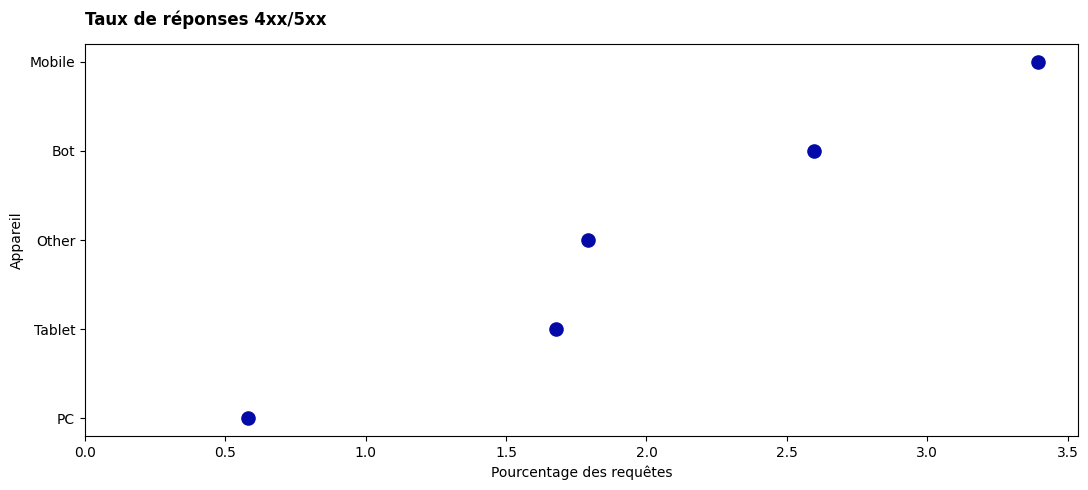

In [14]:
ID_GRAPHIQUE = '01_03'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig, ax = creer_axes()
ax.scatter(a.taux, a.device_type, s=90, color=palette[0]); ax.set_xlim(left=0)
terminer(ax, 'Taux de réponses 4xx/5xx', 'Pourcentage des requêtes', 'Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

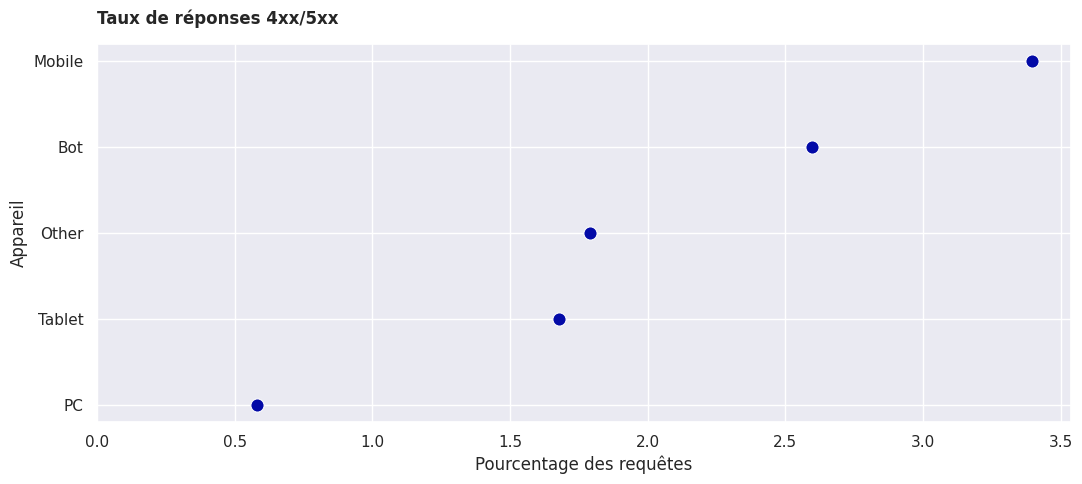

In [15]:
ID_GRAPHIQUE = '01_03'
BIBLIOTHEQUE = 'seaborn'
fig, ax = creer_axes(True)
sns.scatterplot(data=a, x='taux', y='device_type', s=90, color=palette[0], ax=ax); ax.set_xlim(left=0)
ax.invert_yaxis()
terminer(ax, 'Taux de réponses 4xx/5xx', 'Pourcentage des requêtes', 'Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

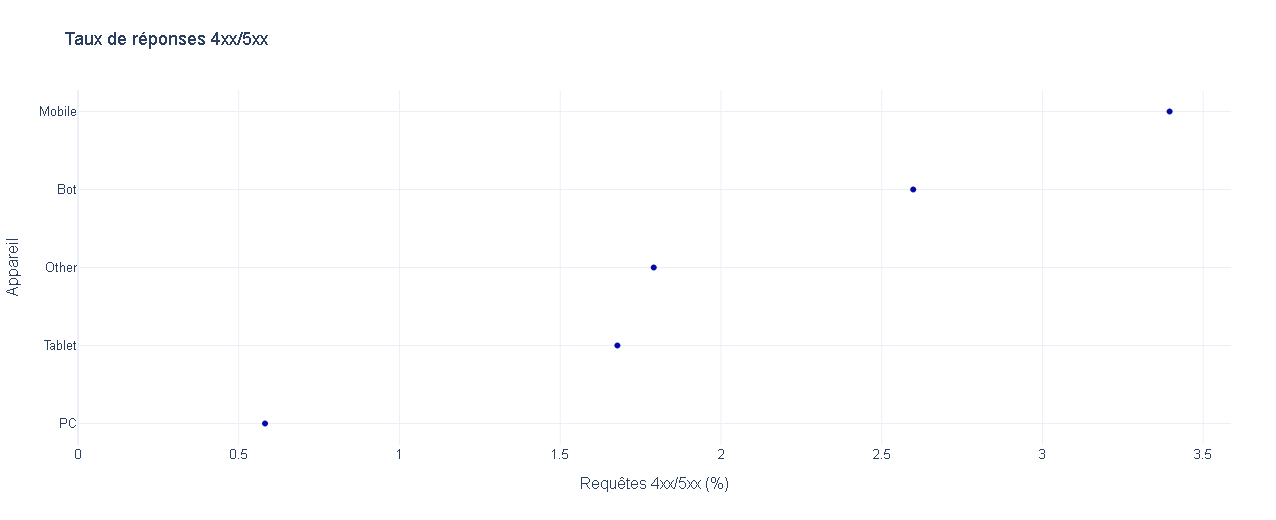

In [16]:
ID_GRAPHIQUE = '01_03'
BIBLIOTHEQUE = 'plotly'
fig = px.scatter(a, x='taux', y='device_type', hover_data=['n'], labels={'taux':'Requêtes 4xx/5xx (%)','device_type':'Appareil'})
fig.update_xaxes(rangemode='tozero')
montrer_plotly(fig, 'Taux de réponses 4xx/5xx')

**À lire dans les trois variantes :** Comparer le taux HTTP 4xx/5xx par appareil. Variables : appareil C + taux Q ; les effectifs affichés permettent de juger les petits groupes.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>4 — Sucettes</div></b>

Classer les huit codes HTTP les plus fréquents. Variables : code C + effectif Q ; les tiges commencent à zéro.

In [17]:
a = donnees.status.value_counts().head(8).sort_values().rename_axis('code').reset_index(name='n'); a['code'] = a['code'].astype(str)
display(a)

,code,n
0,500,104
1,403,320
2,499,2000
3,301,3374
4,404,4588
5,304,8826
6,302,10389
7,200,470348


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

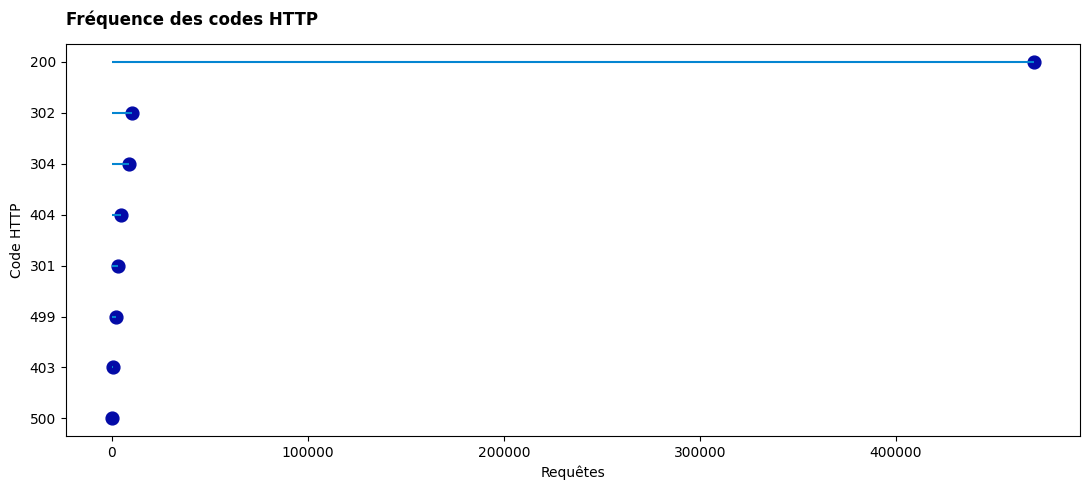

In [18]:
ID_GRAPHIQUE = '01_04'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig, ax = creer_axes()
ax.hlines(a.code, 0, a.n, color=palette[6]); ax.scatter(a.n, a.code, color=palette[0], s=85)
terminer(ax, 'Fréquence des codes HTTP', 'Requêtes', 'Code HTTP')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

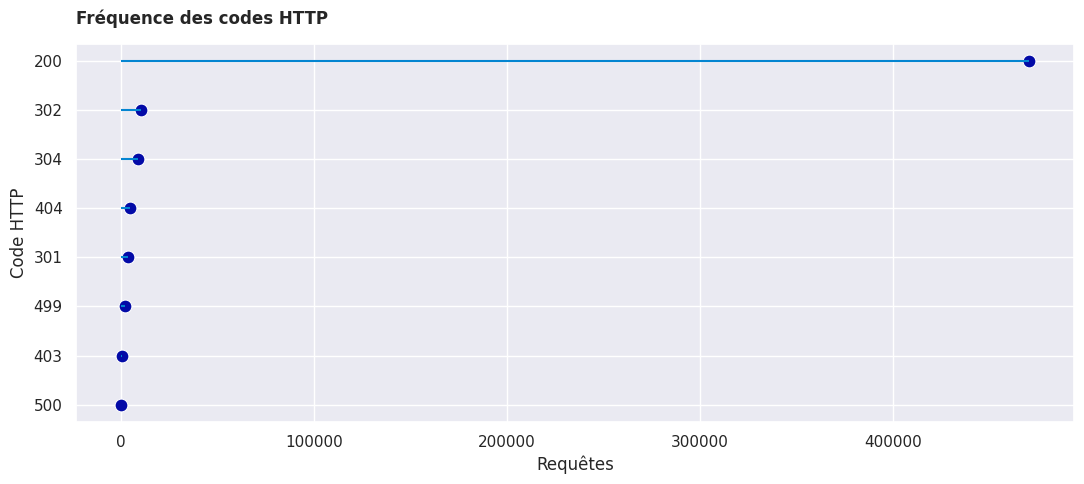

In [19]:
ID_GRAPHIQUE = '01_04'
BIBLIOTHEQUE = 'seaborn'
fig, ax = creer_axes(True)
ax.hlines(a.code, 0, a.n, color=palette[6]); sns.scatterplot(data=a, x='n', y='code', s=85, color=palette[0], ax=ax)
ax.invert_yaxis()
terminer(ax, 'Fréquence des codes HTTP', 'Requêtes', 'Code HTTP')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

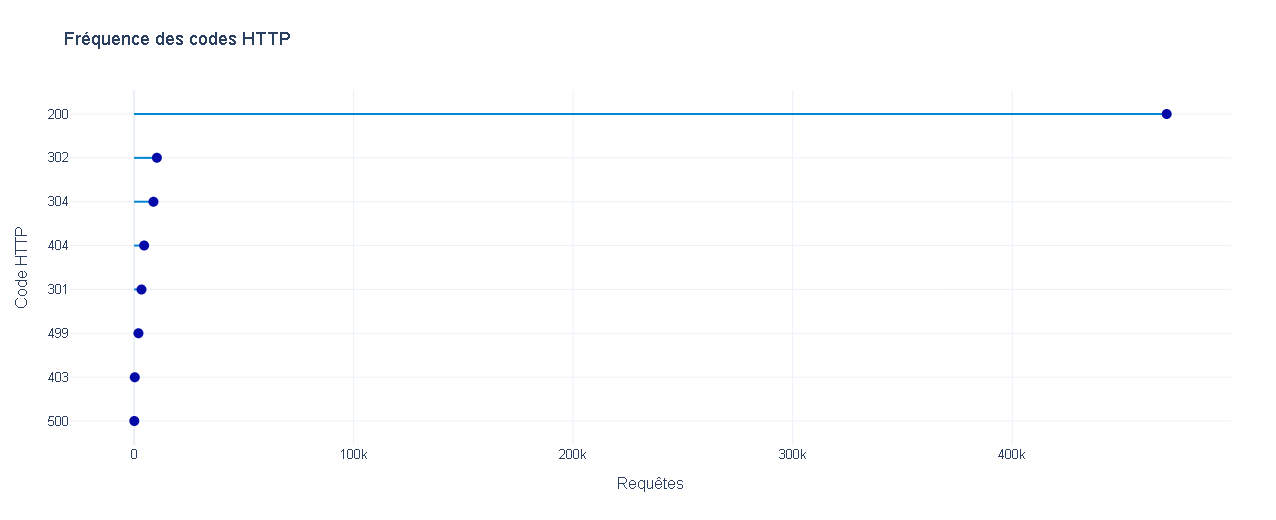

In [20]:
ID_GRAPHIQUE = '01_04'
BIBLIOTHEQUE = 'plotly'
fig = go.Figure()
for r in a.itertuples(): fig.add_trace(go.Scatter(x=[0,r.n], y=[r.code,r.code], mode='lines', line_color=palette[6], showlegend=False))
fig.add_trace(go.Scatter(x=a.n, y=a.code, mode='markers', marker=dict(size=10,color=palette[0]), showlegend=False))
fig.update_layout(xaxis_title='Requêtes', yaxis_title='Code HTTP')
montrer_plotly(fig, 'Fréquence des codes HTTP')

**À lire dans les trois variantes :** Classer les huit codes HTTP les plus fréquents. Variables : code C + effectif Q ; les tiges commencent à zéro.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>5 — Pentes avant et après</div></b>

Comparer deux fenêtres complètes d’une heure, 01–02 UTC et 06–07 UTC, pour les mêmes appareils. Variables : appareil C + fenêtre T + effectif Q ; aucune journée entière n’est extrapolée.

In [21]:
d = donnees.loc[donnees.datetime.dt.hour.isin([1,6])].copy()
d['fenetre'] = np.where(d.datetime.dt.hour.eq(1), '01–02 UTC', '06–07 UTC')
piv = pd.crosstab(d.device_type, d.fenetre).reindex(columns=['01–02 UTC','06–07 UTC'],fill_value=0)
a = piv.rename_axis('appareil').reset_index().melt(id_vars='appareil',var_name='fenetre',value_name='n')
display(piv)

fenetre,01–02 UTC,06–07 UTC
device_type,,
Bot,7355,10443
Mobile,3032,26108
Other,95,1987
PC,3863,105718
Tablet,570,3898


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

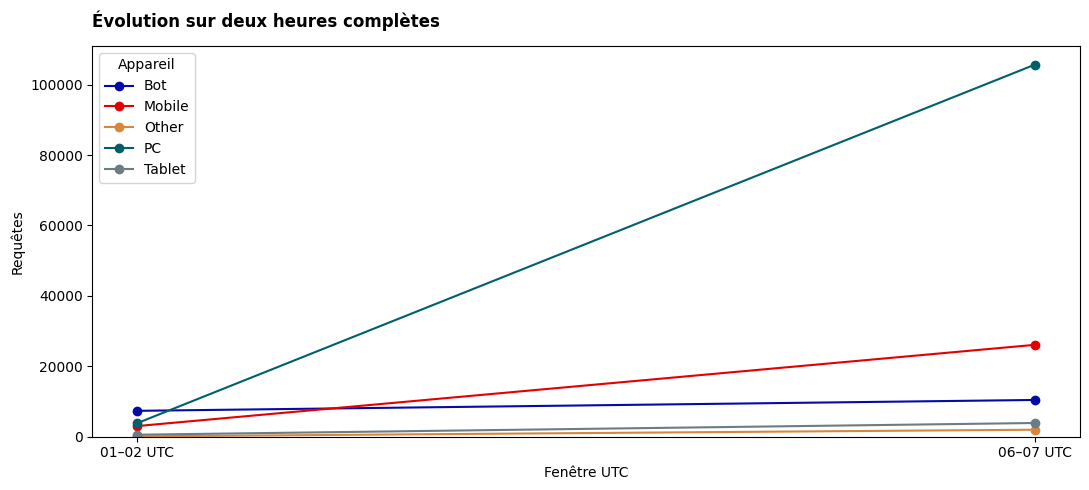

In [22]:
ID_GRAPHIQUE = '01_05'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig, ax = creer_axes()
for j,(nom,r) in enumerate(piv.iterrows()): ax.plot([0,1],r,marker='o',label=nom,color=palette[j])
ax.set_xticks([0,1],piv.columns);ax.legend(title='Appareil');ax.set_ylim(bottom=0)
terminer(ax,'Évolution sur deux heures complètes','Fenêtre UTC','Requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn</div></b>

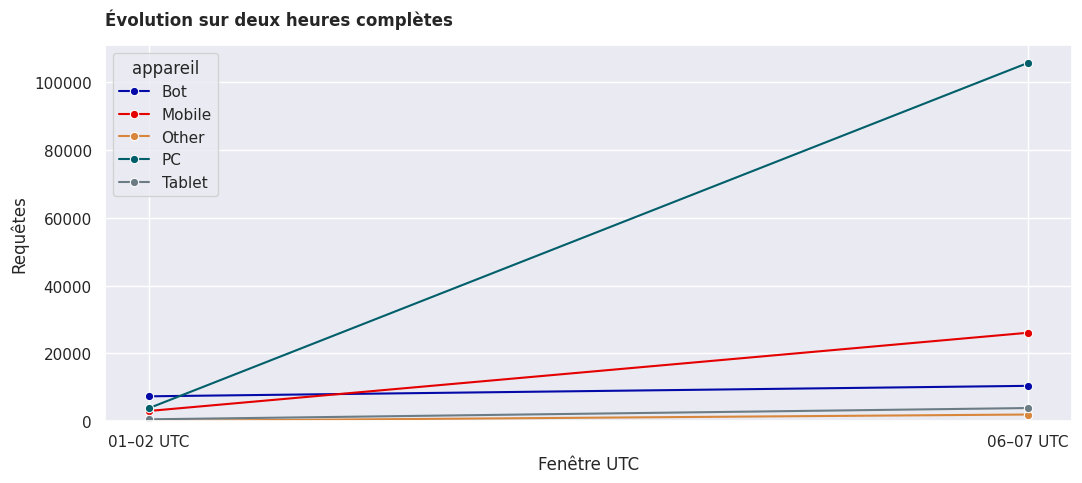

In [23]:
ID_GRAPHIQUE = '01_05'
BIBLIOTHEQUE = 'seaborn'
fig, ax = creer_axes(True)
sns.lineplot(data=a,x='fenetre',y='n',hue='appareil',marker='o',estimator=None,sort=False,palette=palette[:len(piv)],ax=ax);ax.set_ylim(bottom=0)
terminer(ax,'Évolution sur deux heures complètes','Fenêtre UTC','Requêtes')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

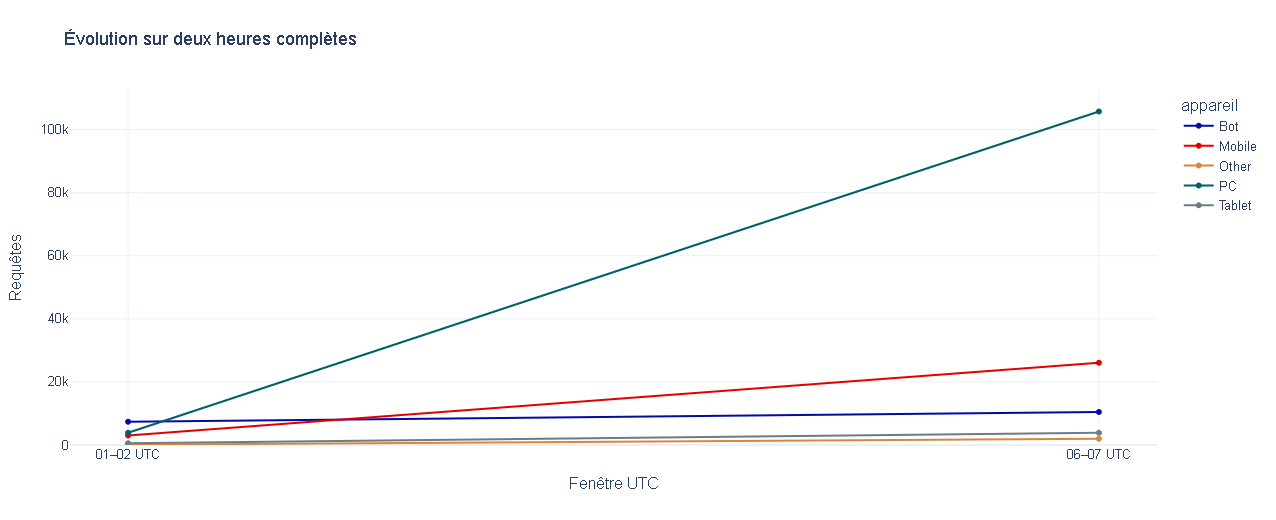

In [24]:
ID_GRAPHIQUE = '01_05'
BIBLIOTHEQUE = 'plotly'
fig=px.line(a,x='fenetre',y='n',color='appareil',markers=True,labels={'n':'Requêtes','fenetre':'Fenêtre UTC'})
fig.update_yaxes(rangemode='tozero')
montrer_plotly(fig,'Évolution sur deux heures complètes')

**À lire dans les trois variantes :** Comparer deux fenêtres complètes d’une heure, 01–02 UTC et 06–07 UTC, pour les mêmes appareils. Variables : appareil C + fenêtre T + effectif Q ; aucune journée entière n’est extrapolée.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>6 — Haltères</div></b>

Comparer médiane et 90e percentile de taille des réponses par appareil. Variables : appareil C + deux statistiques Q dans la même unité ; le segment ne représente pas un intervalle de confiance.

In [25]:
a=donnees.groupby('device_type').taille_ko.agg(mediane='median',p90=lambda x:x.quantile(.9)).sort_values('mediane').reset_index()
long=a.melt(id_vars='device_type',var_name='statistique',value_name='ko')
display(a)

,device_type,mediane,p90
0,Other,2.375,33.713477
1,PC,2.728516,30.03418
2,Tablet,4.069336,10.12793
3,Mobile,5.395508,27.867188
4,Bot,27.898438,39.67793


### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Matplotlib</div></b>

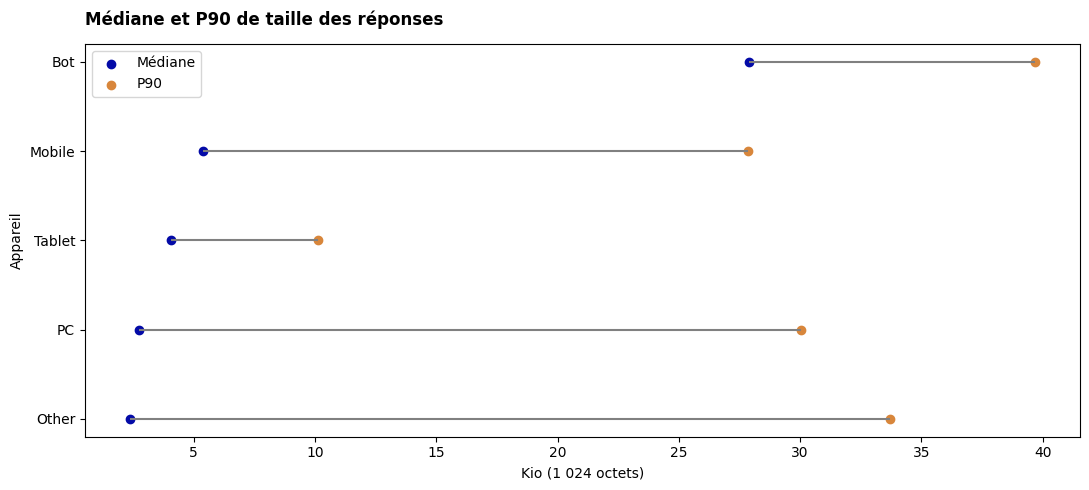

In [26]:
ID_GRAPHIQUE = '01_06'
BIBLIOTHEQUE = 'matplotlib'
plt.style.use('default')
fig,ax=creer_axes()
ax.hlines(a.device_type,a.mediane,a.p90,color='gray');ax.scatter(a.mediane,a.device_type,label='Médiane',color=palette[0]);ax.scatter(a.p90,a.device_type,label='P90',color=palette[2]);ax.legend()
terminer(ax,'Médiane et P90 de taille des réponses','Kio (1 024 octets)','Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Seaborn — composition avec Matplotlib</div></b>

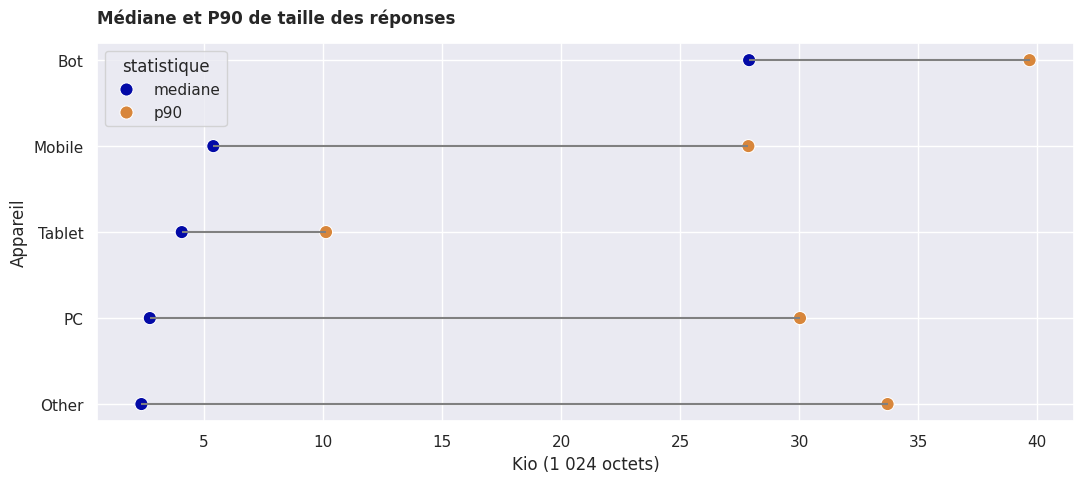

In [27]:
ID_GRAPHIQUE = '01_06'
BIBLIOTHEQUE = 'seaborn'
fig,ax=creer_axes(True)
ax.hlines(a.device_type,a.mediane,a.p90,color='gray');sns.scatterplot(data=long,x='ko',y='device_type',hue='statistique',s=90,palette=[palette[0],palette[2]],ax=ax)
ax.invert_yaxis()
terminer(ax,'Médiane et P90 de taille des réponses','Kio (1 024 octets)','Appareil')

### <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Plotly</div></b>

In [28]:
ID_GRAPHIQUE = '01_06'
BIBLIOTHEQUE = 'plotly'
fig=go.Figure()
for r in a.itertuples(): fig.add_trace(go.Scatter(x=[r.mediane,r.p90],y=[r.device_type]*2,mode='lines',line_color='gray',showlegend=False))
for col,c in [('mediane',palette[0]),('p90',palette[2])]:fig.add_trace(go.Scatter(x=a[col],y=a.device_type,mode='markers',name=col,marker=dict(color=c,size=10)))
fig.update_layout(xaxis_title='Kio (1 024 octets)',yaxis_title='Appareil')
montrer_plotly(fig,'Médiane et P90 de taille des réponses')

**À lire dans les trois variantes :** Comparer médiane et 90e percentile de taille des réponses par appareil. Variables : appareil C + deux statistiques Q dans la même unité ; le segment ne représente pas un intervalle de confiance.

**Vérification :** mêmes valeurs, mêmes unités et même périmètre ; seule la bibliothèque change.

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Synthèse et exercices</div></b>

1. Reformuler la question métier de chacun des six graphiques.
2. Modifier un filtre ou une période et expliquer son effet sur le dénominateur.
3. Choisir une variante pour un rapport imprimé et une pour un tableau de bord interactif.
4. Vérifier l’unité, l’effectif, les valeurs manquantes et le sens des encodages.

**Limites :** Le fichier couvre seulement le 22 janvier 2019, de 00:26 à 07:36 UTC environ. Les premières et dernières minutes sont incomplètes. Les mesures portent sur des requêtes, pas sur des personnes. Les adresses IP et URL brutes ne sont pas chargées.